In [125]:
import numpy as np
import pandas as pd
from pathlib import Path


In [126]:
cwd=Path.cwd()
parrent_dir=cwd.parent
print(parrent_dir)
# Read the csv file
df = pd.read_csv(parrent_dir/'data'/'appartment.csv')
df.head(10)

d:\bits\Sem3\mloops Projects\ml-project-banglore-flats


,apartment_name,appartment_loc,zone,bhk_type,construction_status,carpet_area,bulit_area,super_bulit_area,price_value,nearbylocation,facility
0,"Sattva Songbird Old Madras Road, Bangalore","Old Madras Road, Bangalore",east,1,Under Construction,510 sq.ft,NaN,NaN,1.1 Cr+ Charges,"[('rcb int school', '7.3 km'), ('garden city u...","[""Children's Play Area"", 'Park', 'Gymnasium', ..."
1,"Brigade Sanctuary Chikkavaderapura, near Varthur","Chikkavaderapura, near Varthur",east,1,Under Construction,NaN,NaN,656 sq.ft,87.53 L+ Charges,"[('oakridge international school bangalore', '...","[""Children's Play Area"", 'Creche/Day Care', 'J..."
2,"Sobha Neopolis Panathur, Bangalore","Panathur, Bangalore",east,1,New Launch,435 sq.ft,NaN,NaN,89 L+ Charges,"[('sarah montessori school', '1.4 kms'), ('h '...","['Yoga/Meditation Area', 'Jogging Track', 'Ska..."
3,"Nambiar Millennia Sarjapur Road, Bangalore","Sarjapur Road, Bangalore",east,1,Under Construction,NaN,668 sq.ft,NaN,53.28 - 53.44 L+ Charges,"[('mahatma vidhyalaya', '400 m'), ('eterssrt m...","['Yoga/Meditation Area', ""Children's Play Area..."
4,"Provident Capella Samethanahalli, Near Whitefield","Samethanahalli, Near Whitefield",east,1,Partially Ready To Move,NaN,NaN,390 - 570 sq.ft,44.63 - 65.23 L+ Charges,"[('soukya road', '1.4 km'), ('mvj college of e...","[""Children's Play Area"", 'Creche/Day Care', 'J..."
5,"Brigade Citrine Budigere Cross, Bangalore","Byrathi, near Hennur Road",east,1,New Launch,NaN,NaN,689 sq.ft,68.89 L+ Charges,"[('one world international school', '3.2kms'),...","['Pet Park', ""Children's Play Area"", 'Landscap..."
6,"Sattva East Crest Bandapura, Old Madras Road","Budigere Cross, Bangalore",east,1,Ready To Move,NaN,NaN,598 sq.ft,70 L+ Charges,"[('prerana international school', '700 m'), ('...","['Banquet Hall', 'Creche/Day Care', ""Children'..."
7,"Akarsha Adarsh Parkland Panathur, Bangalore","Bandapura, Old Madras Road",east,1,New Launch,419.79 sq.ft,NaN,NaN,73.33 L+ Charges,"[('vibgyor rise school', '1.6 km'), ('brookefi...","['Yoga/Meditation Area', 'Creche/Day Care', 'S..."
8,"Mana Capitol Sarjapur Road, Bangalore","Panathur, Bangalore",east,1,Ready To Move,432.5 - 433 sq.ft,NaN,NaN,72.1 - 83.39 L+ Charges,"[('enzyme office complex', '300 m'), ('karmela...","['Banquet Hall', ""Children's Play Area"", 'Crec..."
9,"Sobha Sentosa Balagere, near Panathur","Sarjapur Road, Bangalore",east,1,Under Construction,422.49 - 434.14 sq.ft,NaN,NaN,88.4 - 90.3 L+ Charges,"[('orchids the international school', '3.6 kms...","[""Children's Play Area"", 'Jogging Track', 'Ska..."


In [127]:
# Drop duplicates
print("Number of duplicates: ", df.duplicated().sum())
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
# shape of the dataframe
df.duplicated().sum()

Number of duplicates:  0


np.int64(0)

In [128]:
# shape of the dataframe
df.shape

(6662, 11)

In [129]:
# Find the null values

df.isnull().sum()

apartment_name            0
appartment_loc            0
zone                      0
bhk_type                  0
construction_status       3
carpet_area            2874
bulit_area             4796
super_bulit_area       2604
price_value               0
nearbylocation          303
facility                538
dtype: int64

In [130]:
# dtypes of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6662 entries, 0 to 6661
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   apartment_name       6662 non-null   object
 1   appartment_loc       6662 non-null   object
 2   zone                 6662 non-null   object
 3   bhk_type             6662 non-null   int64 
 4   construction_status  6659 non-null   object
 5   carpet_area          3788 non-null   object
 6   bulit_area           1866 non-null   object
 7   super_bulit_area     4058 non-null   object
 8   price_value          6662 non-null   object
 9   nearbylocation       6359 non-null   object
 10  facility             6124 non-null   object
dtypes: int64(1), object(10)
memory usage: 572.6+ KB


In [131]:
df['apartment_name'].value_counts()

apartment_name
in kvg superior                  133
in Prestige Waterford             76
in Prestige Finsbury Park         72
in Purva Atmosphere               54
in Brigade El Dorado              51
                                ... 
in Vibrant Advaitha                1
in Nandi Prime                     1
in urban residency                 1
in Prathibimba Platinum Purva      1
in DS Max Silicon                  1
Name: count, Length: 2718, dtype: int64

In [132]:
# starts with 'in' replace it with ''

df['apartment_name'] = (
                        df['apartment_name']
                        .str.replace('in', '')
                        .str.split(',')
                        .str[0]
                    )


In [134]:
df['appartment_loc'].value_counts()

appartment_loc
Whitefield, Bangalore                      471
Bagalur, Bangalore                         204
Hebbal, Bangalore                          181
Sarjapur Road, Bangalore                   173
Thanisandra, Bangalore                     151
                                          ... 
Dwarka Nagar, Bagalur Main Road              1
ITPL, Bangalore                              1
Huskur, near Hoskote                         1
Mandur, Bangalore                            1
HOSKEREHALLI, Bangalore East, Bangalore      1
Name: count, Length: 888, dtype: int64

In [135]:
df['appartment_loc']=df['appartment_loc'].apply(lambda x : x.split(',')[0].strip() if ','in x else x.strip())

In [136]:
def apartment_rectification(x):
    if  x.iloc[1].lower() in x.iloc[0].lower():
        return x.iloc[0].lower().replace(x.iloc[1].lower(),'').strip()
    else:
        return x.iloc[0].lower().strip()
    

In [137]:
df['apartment_name']  = df[['apartment_name','appartment_loc']].apply(apartment_rectification,axis=1)

In [138]:
df['apartment_name']

0           sattva songbird
1         brigade sanctuary
2            sobha neopolis
3         nambiar millennia
4         provident capella
               ...         
6657     prestige jdal city
6658    prestige west woods
6659       arge urban bloom
6660         sobha rajvilas
6661          lea sunflower
Name: apartment_name, Length: 6662, dtype: object

In [139]:
df.columns

Index(['apartment_name', 'appartment_loc', 'zone', 'bhk_type',
       'construction_status', 'carpet_area', 'bulit_area', 'super_bulit_area',
       'price_value', 'nearbylocation', 'facility'],
      dtype='object')

In [140]:
# different zones in the dataframe
print("Number of zones: ", df['zone'].isnull().sum())
df['zone'].value_counts()

Number of zones:  0


zone
east     2331
north    2019
south    1494
west      818
Name: count, dtype: int64

In [141]:
# no of bedrooms in the dataframe
print("Number of bedrooms: ", df['bhk_type'].isnull().sum())
df['bhk_type'].value_counts()

Number of bedrooms:  0


bhk_type
3    2619
2    2405
4    1074
1     564
Name: count, dtype: int64

In [142]:
df.columns

Index(['apartment_name', 'appartment_loc', 'zone', 'bhk_type',
       'construction_status', 'carpet_area', 'bulit_area', 'super_bulit_area',
       'price_value', 'nearbylocation', 'facility'],
      dtype='object')

In [143]:
print("no of missing values in construction_status : ",df['construction_status'].isnull().sum())
df['construction_status'].value_counts()

no of missing values in construction_status :  3


construction_status
1 to 5 Year Old       2069
0 to 1 Year Old       1492
5 to 10 Year Old       825
Under Construction     446
10+ Year Old           356
                      ... 
28-Oct                   2
28-Apr                   2
28-Aug                   2
28-Nov                   1
31-May                   1
Name: count, Length: 68, dtype: int64

In [144]:
df[df['construction_status'].isnull()]

,apartment_name,appartment_loc,zone,bhk_type,construction_status,carpet_area,bulit_area,super_bulit_area,price_value,nearbylocation,facility
763,brigade cornerstone utopia,Varthur,east,2,NaN,483.08 sq.ft,NaN,854 sq.ft,1.1 Cr,"['Seetharam Palya Metro Station', 'Central Mal...","['Power Back-up', 'Intercom Facility', 'Lift(s..."
1285,candeur signature,Varthur,east,3,NaN,984.9 sq.ft,1190 sq.ft,1590 sq.ft,2.5 Cr,"['Sansar Center Hyper Market', 'SH 35, Devasth...","['Feng Shui / Vaastu Compliant', 'Lift(s)', 'S..."
6559,mahaveer mason,Mahaganapathi Nagar,west,3,NaN,NaN,NaN,1806 sq.ft,1.95 Cr,"['Hanuman Temple', 'Anjaneya Ganesha Temple', ...","['Intercom Facility', 'Lift(s)', 'Swimming Poo..."


## Carpet Area

In [145]:
print("no of missing values in carpet_area : ",df['carpet_area'].isnull().sum())
df['carpet_area'].value_counts()

no of missing values in carpet_area :  2874


carpet_area
1100 sq.ft    89
900 sq.ft     74
1200 sq.ft    67
1000 sq.ft    58
1500 sq.ft    43
              ..
1785 sq.ft     1
1319 sq.ft     1
3528 sq.ft     1
1684 sq.ft     1
1681 sq.ft     1
Name: count, Length: 1383, dtype: int64

In [146]:
def clean_carpet_super_built_area(x):
    if not isinstance(x, str):
        return x  # Return as is if not a string (handles NaN)
    
    # Remove sq.ft and strip spaces
    x = x.replace(' sq.ft', '').strip()
    
    # Remove any trailing periods
    if x.endswith('.'):
        x = x[:-1]
    
    # Handle ranges with hyphen
    if '-' in x:
        try:
            first = (x.split('-')[0].strip())
            second = (x.split('-')[1].strip())
            return round((float(first) + float(second)) / 2)
        except:
            return None  
    
    # Convert single value
    try:
        return float(x)
    except:
        return None  

In [147]:
df['carpet_area']=df['carpet_area'].apply(clean_carpet_super_built_area)

In [148]:
print ("no of missing values in carpet_area : ",df['carpet_area'].isnull().sum())
df['carpet_area'].describe()

no of missing values in carpet_area :  2874


count    3788.000000
mean     1360.155058
std       897.065369
min        10.000000
25%       851.500000
50%      1131.000000
75%      1520.000000
max      7825.000000
Name: carpet_area, dtype: float64

In [150]:
df[df['carpet_area'] > 2500]

,apartment_name,appartment_loc,zone,bhk_type,construction_status,carpet_area,bulit_area,super_bulit_area,price_value,nearbylocation,facility
1263,brigade exotica,Old Madras Road,east,3,1 to 5 Year Old,3010.0,NaN,NaN,3.8 Cr,"['Decathlon Old Madras Road', 'Orion UPTOWN Ma...","['Power Back-up', 'Intercom Facility', 'Lift(s..."
1388,the grand edifice,Hoskote,east,3,10+ Year Old,3120.0,NaN,NaN,1.25 Cr,"['G E F Eye Hospital', 'Shreyas Maternity Home...","['Security / Fire Alarm', 'Feng Shui / Vaastu ..."
1438,yafa zaifar,HBR Layout,east,3,5 to 10 Year Old,2725.0,2950 sq.ft,NaN,2.2 Cr,"['Springfield A.G. Church', 'Masjid-e-Yusuf', ...","['Feng Shui / Vaastu Compliant', 'Security / F..."
1582,total environment pursuit of a radical rhapsody,Hoodi,east,3,25-Dec,3200.0,3600 sq.ft,4100 sq.ft,8.25 Cr,"['ITPL Metro Station', 'SM gents world', 'NH 4...","['Centrally Air Conditioned', 'Water purifier'..."
1583,total environment pursuit of a radical rhapsody,Hoodi,east,3,0 to 1 Year Old,2753.0,NaN,NaN,5.15 Cr,"['ITPL Metro Station', 'SM gents world', 'NH 4...","['Feng Shui / Vaastu Compliant', 'Lift(s)', 'M..."
...,...,...,...,...,...,...,...,...,...,...,...
6640,phoenix kessaku,Rajajinagar,west,4,1 to 5 Year Old,3000.0,3500 sq.ft,4053 sq.ft,7 Cr,"['Vivekananda Degree College', 'East West Publ...","['Intercom Facility', 'Lift(s)', 'Maintenance ..."
6641,phoenix kessaku,Rajajinagar,west,4,1 to 5 Year Old,3500.0,NaN,3766 sq.ft,7 Cr,"['Vivekananda Degree College', 'East West Publ...","['Centrally Air Conditioned', 'Water purifier'..."
6643,phoenix kessaku,Rajajinagar,west,4,1 to 5 Year Old,3500.0,NaN,3715 sq.ft,7 Cr,"['Vivekananda Degree College', 'East West Publ...","['Water purifier', 'Security / Fire Alarm', 'F..."
6653,shri sai associates,Sadashiva Nagara,west,4,0 to 1 Year Old,3850.0,4150 sq.ft,4650 sq.ft,13.2 Cr,"['Prasanna Anjaneya Temple', 'Canara bank ATM'...","['High Ceiling Height', 'Maintenance Staff', '..."


## Built up area


In [151]:
df['bulit_area']

0              NaN
1              NaN
2              NaN
3        668 sq.ft
4              NaN
           ...    
6657           NaN
6658    2200 sq.ft
6659    1713 sq.ft
6660           NaN
6661    3037 sq.ft
Name: bulit_area, Length: 6662, dtype: object

In [152]:
df['bulit_area']=df['bulit_area'].apply(clean_carpet_super_built_area)

In [153]:
print ("no of missing values in bulit_area : ",df['bulit_area'].isnull().sum())

df['bulit_area'].describe()

no of missing values in bulit_area :  4796


count    1866.000000
mean     1687.846924
std      1070.660112
min        27.000000
25%      1100.000000
50%      1359.000000
75%      1888.750000
max      8000.000000
Name: bulit_area, dtype: float64

## Supper built up area

In [154]:
df['super_bulit_area'] = df['super_bulit_area'].apply(clean_carpet_super_built_area)

In [155]:
print ("no of missing values in super_bulit_area : ",df['bulit_area'].isnull().sum())

df['super_bulit_area'].describe()

no of missing values in super_bulit_area :  4796


count    4058.000000
mean     1746.936180
std      1063.482861
min        31.840000
25%      1128.500000
50%      1430.000000
75%      1974.750000
max      7900.000000
Name: super_bulit_area, dtype: float64

In [92]:
df.columns

Index(['apartment_name', 'appartment_loc', 'zone', 'bhk_type',
       'construction_status', 'carpet_area', 'bulit_area', 'super_bulit_area',
       'price_value', 'nearbylocation', 'facility'],
      dtype='object')

In [157]:
def clean_price(x):
  # List of special non-numeric values to handle
    special_cases = [
        'Available on Request', 'On Request', 'Price on Request'
    ]
    
    # Check for special cases first
    for case in special_cases:
        if case.lower() in x.lower():
            return None  # or any other default value you prefer
    

    # Make a copy of x to avoid modifying the original
    original_x = x
    processed_x = x
    
    # Determine the unit type first (to apply conversion later)
    is_lakh = any(unit in original_x for unit in ['Lac', 'L', 'L+', 'Lakh', 'Lakhs'])
    
    # Remove all currency indicators
    indicators = ['Cr+ Charges', 'L+ Charges', 'Lac', 'Cr', 'L', 'Lakh', 'Lakhs', 'Crore', 'Crores']
    for indicator in indicators:
        if indicator in processed_x:
            processed_x = processed_x.replace(indicator, '')
    
    processed_x = processed_x.strip()
    
    # Handle range values
    if '-' in processed_x:
        parts = processed_x.split('-')
        min_val = float(parts[0].strip())
        max_val = float(parts[1].strip())
        value = round((min_val + max_val) / 2, 2)
    else:
        value = float(processed_x)
    
    # Convert to Crores based on the original unit
    if is_lakh:
        # Convert from Lakhs to Crores (1 Crore = 100 Lakhs)
        return round(value / 100, 2)
    else:
        # Already in Crores or no unit specified
        return round(value, 2)


In [158]:
df['price_value'] = df['price_value'].apply(clean_price)

In [159]:
df['price_value'].describe()

count    6660.000000
mean        1.908320
std         1.924137
min         0.090000
25%         0.760000
50%         1.200000
75%         2.302500
max        21.420000
Name: price_value, dtype: float64

In [162]:
rows_to_drop = df[(df['carpet_area'].isnull()) &(df['bulit_area'].isnull()) & (df['super_bulit_area'].isnull())].index
print("rows to drop: ", rows_to_drop)

rows to drop:  Index([ 197,  198,  206,  208,  212,  214,  215,  217,  220,  223,  228,  239,
        257,  269,  912,  915,  919,  921, 1738, 1739, 1740, 1742, 1743, 1745,
       1746, 1747, 1753, 1757, 1758, 1759, 1760, 1761, 1772, 1778, 1783, 1786,
       1787, 1790, 1796, 2347, 2376, 2557, 2887, 2895, 3994, 4421, 4524, 4527,
       4541, 5125, 5160, 5165, 5298, 5707, 5840, 5845, 5846, 5910, 5911, 5915,
       5918, 5928, 5933, 5938, 6038, 6212, 6223, 6224, 6225, 6231, 6235, 6336,
       6589, 6590],
      dtype='int64')


In [163]:
# drop rows
df.drop(rows_to_drop, inplace=True)
df.reset_index(drop=True, inplace=True)

In [164]:
df.columns

Index(['apartment_name', 'appartment_loc', 'zone', 'bhk_type',
       'construction_status', 'carpet_area', 'bulit_area', 'super_bulit_area',
       'price_value', 'nearbylocation', 'facility'],
      dtype='object')

In [165]:
df['construction_status'].unique()

array(['Under Construction', 'New Launch', 'Partially Ready To Move',
       'Ready To Move', '0 to 1 Year Old', '1 to 5 Year Old',
       'Within 3 months', '5 to 10 Year Old', 'Within 6 months', '25-Jan',
       '10+ Year Old', '25-May', '25-Jun', '26-Mar', '27-Jul', '27-Apr',
       '25-Mar', 'undefined', '25-Oct', '25-Jul', '25-Aug', '25-Feb',
       '28-Dec', '27-Nov', '25-Dec', 'By 2025', '26-Dec', '25-Apr',
       '28-Feb', '25-Sep', '27-Jun', '26-Jul', '26-Oct', 'By 2026',
       '26-Apr', '28-Jul', nan, '28-Jun', 'By 2024', '26-Aug', '27-Feb',
       '28-Mar', '26-Jan', '26-Jun', '27-Mar', '26-Sep', '25-Nov',
       '26-Feb', '26-Nov', '27-Aug', '27-Dec', '27-May', '28-Nov',
       '27-Sep', '29-May', '29-Dec', '28-Sep', '27-Oct', 'By 2027',
       '28-Jan', '28-Oct', '28-May', '28-Aug', '31-May', '29-Jun',
       'By 2028', '27-Jan', '29-Jul', '28-Apr'], dtype=object)

In [166]:
def categorize_age_possession(value):
    # Handle NaN/None values
    if pd.isna(value):
        return "undefined"
    
    # Convert to string if value is not already a string
    if not isinstance(value, str):
        return "undefined"
    
    # Lists for categorization
    new_prop_list = ['New Launch', 'Ready To Move', 'Within 3 months', 'Within 6 months', '0 to 1 Year Old', 'Partially Ready To Move']
    under_const_list = ['Partially Ready To Move', 'Under Construction']
    
    # Check if value is in new property list
    if value in new_prop_list:
        return 'New Property'
    
    # Check specific age ranges
    if "1 to 5 Year Old" == value:
        return "Relatively New"
    if "5 to 10 Year Old" == value:
        return "Moderatly Old"
    if "10+ Year Old" == value:
        return "Old"
    
    # Check if under construction
    if value in under_const_list or 'By' in value:
        return "Under Construction"
    
    # Try to check numeric values for under construction properties
    try:
        if value.split('-')[0].strip().isnumeric():
            return "Under Construction"
    except (AttributeError, IndexError):
        pass
    
    # Default case
    return "undefined"

In [167]:
df['construction_status'] = df['construction_status'].apply(categorize_age_possession)

In [168]:
print("missing values in construction_status : ",df['construction_status'].isnull().sum())
df['construction_status'].value_counts()

missing values in construction_status :  0


construction_status
New Property          2087
Relatively New        2069
Under Construction    1180
Moderatly Old          825
Old                    356
undefined               71
Name: count, dtype: int64

In [169]:
df

,apartment_name,appartment_loc,zone,bhk_type,construction_status,carpet_area,bulit_area,super_bulit_area,price_value,nearbylocation,facility
0,sattva songbird,Old Madras Road,east,1,Under Construction,510.0,NaN,NaN,1.10,"[('rcb int school', '7.3 km'), ('garden city u...","[""Children's Play Area"", 'Park', 'Gymnasium', ..."
1,brigade sanctuary,Chikkavaderapura,east,1,Under Construction,NaN,NaN,656.0,0.88,"[('oakridge international school bangalore', '...","[""Children's Play Area"", 'Creche/Day Care', 'J..."
2,sobha neopolis,Panathur,east,1,New Property,435.0,NaN,NaN,0.89,"[('sarah montessori school', '1.4 kms'), ('h '...","['Yoga/Meditation Area', 'Jogging Track', 'Ska..."
3,nambiar millennia,Sarjapur Road,east,1,Under Construction,NaN,668.0,NaN,0.53,"[('mahatma vidhyalaya', '400 m'), ('eterssrt m...","['Yoga/Meditation Area', ""Children's Play Area..."
4,provident capella,Samethanahalli,east,1,New Property,NaN,NaN,480.0,0.55,"[('soukya road', '1.4 km'), ('mvj college of e...","[""Children's Play Area"", 'Creche/Day Care', 'J..."
...,...,...,...,...,...,...,...,...,...,...,...
6583,prestige jdal city,Tumkur Road,west,4,Relatively New,1520.0,NaN,2171.0,2.50,"['Nagasandra', 'BIEC', 'AH 47', 'Soundarya Art...","['Security / Fire Alarm', 'Power Back-up', 'Fe..."
6584,prestige west woods,Okalipuram,west,4,Relatively New,2000.0,2200.0,2500.0,3.85,"['Krantiveera Sangolli Rayanna Metro', 'Lulu M...","['Centrally Air Conditioned', 'Water purifier'..."
6585,arge urban bloom,Yeshwanthpur,west,4,undefined,1162.0,1713.0,NaN,2.75,"['Metro Station', 'Ambika traders APMC YARD Ma...",NaN
6586,sobha rajvilas,Rajajinagar,west,4,New Property,1429.0,NaN,2171.0,5.00,"['KSR Metro Station', 'Lulu Mall Bengaluru', '...","['Intercom Facility', 'Lift(s)', 'Separate ent..."


In [170]:
df['bhk_type'] = df['bhk_type'].astype('category')

In [107]:
df.columns

Index(['apartment_name', 'appartment_loc', 'zone', 'bhk_type',
       'construction_status', 'carpet_area', 'bulit_area', 'super_bulit_area',
       'price_value', 'nearbylocation', 'facility'],
      dtype='object')

In [171]:
df['facility'].isnull().sum()

np.int64(535)

In [172]:
import ast

from sklearn.preprocessing import MultiLabelBinarizer


# Convert the string representation of lists in the 'features' column to actual lists
df['facility_list'] = df['facility'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])
# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['facility_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [173]:
features_binary_df

,24/7 Power Backup,24/7 Water Supply,24x7 Security,ATM,Acupressure Park,Aerobics Centre,Airy Rooms,Amphitheatre,Badminton Court,Bank Attached Property,...,Vastu Compliant,Video Door Security,Visitor Parking,Volley Ball Court,Waste Disposal,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6583,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,1,0,0,0,0
6584,0,0,0,0,0,0,1,0,0,1,...,0,0,1,0,1,1,1,1,0,0
6585,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6586,0,0,0,0,0,0,1,0,0,0,...,0,0,1,0,1,0,0,0,0,0


In [174]:
from sklearn.cluster import KMeans


wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(features_binary_df)
    wcss_reduced.append(kmeans.inertia_)

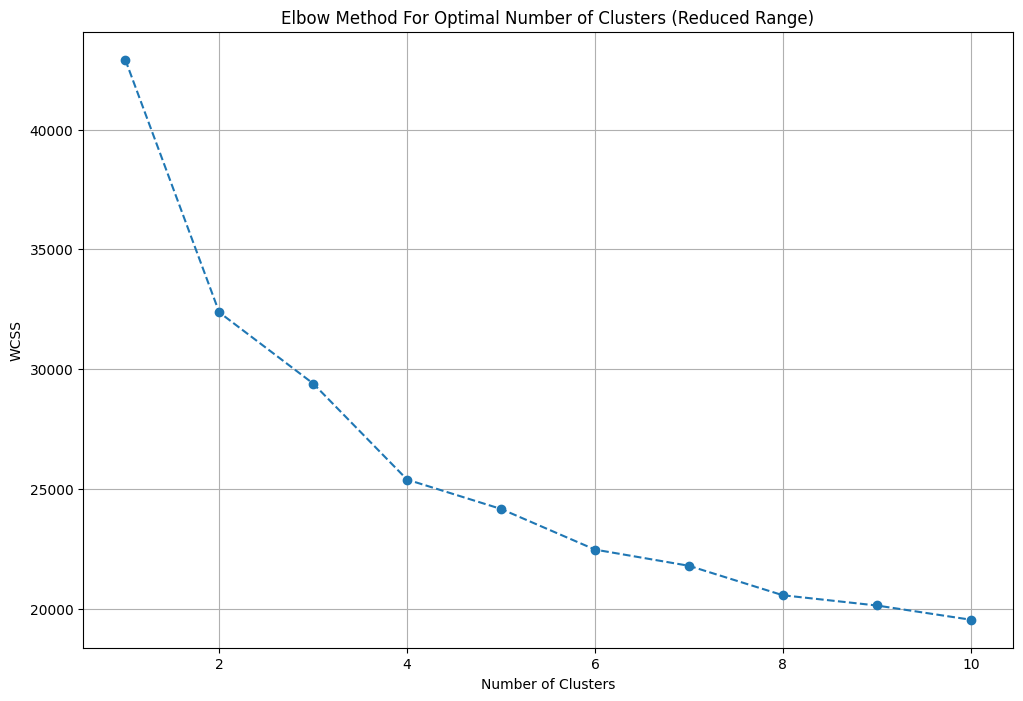

In [175]:
# Plot the results
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [176]:
list(mlb.classes_)

['24/7 Power Backup',
 '24/7 Water Supply',
 '24x7 Security',
 'ATM',
 'Acupressure Park',
 'Aerobics Centre',
 'Airy Rooms',
 'Amphitheatre',
 'Badminton Court',
 'Bank Attached Property',
 'Banquet Hall',
 'Barbecue',
 'Basketball Court',
 'Beach Volley Ball Court',
 'Billiards',
 'Business Lounge',
 'CCTV Camera Security',
 'Cafeteria',
 'Car Parking',
 'Carrom',
 'Centrally Air Conditioned',
 'Changing Area',
 'Chess',
 "Children's Play Area",
 'Club House',
 'Club house / Community Center',
 'Community Hall',
 'Conference Room',
 'Creche/Day Care',
 'Cricket Pitch',
 'Cycling Track',
 'EV Charging Stations',
 'Earthquake Resistant',
 'False Ceiling Lighting',
 'Feng Shui / Vaastu Compliant',
 'Fire Fighting Systems',
 'Fitness Centre / GYM',
 'Flower Garden',
 'Foosball',
 'Football Ground',
 'Fountain',
 'Gated Community',
 'Gazebo',
 'Golf Course',
 'Grocery Shop',
 'Gymnasium',
 'High Ceiling Height',
 'Indoor Games',
 'Intercom',
 'Intercom Facility',
 'Internal Street Lights'

In [177]:
luxury_facility_scores = {
    "24/7 Power Backup": 6,  # Expected in luxury, not distinctive
    "24/7 Water Supply": 6,  # Basic expectation
    "24x7 Security": 7,
    "ATM": 3,  # Convenience, not luxury
    "Acupressure Park": 7,
    "Aerobics Centre": 7,
    "Airy Rooms": 8,  # Spatial luxury
    "Amphitheatre": 8,
    "Badminton Court": 6,
    "Bank Attached Property": 4,
    "Banquet Hall": 9,
    "Barbecue": 7,
    "Basketball Court": 6,
    "Beach Volley Ball Court": 8,
    "Billiards": 8,
    "Business Lounge": 8,
    "CCTV Camera Security": 6,  # Expected
    "Cafeteria": 5,
    "Car Parking": 6,  # Basic expectation
    "Carrom": 4,
    "Centrally Air Conditioned": 9,
    "Changing Area": 5,
    "Chess": 4,
    "Children's Play Area": 6,
    "Club House": 9,
    "Club house / Community Center": 9,
    "Community Hall": 7,
    "Conference Room": 7,
    "Creche/Day Care": 8,
    "Cricket Pitch": 7,
    "Cycling Track": 7,
    "EV Charging Stations": 8,  # Modern luxury
    "Earthquake Resistant": 5,  # Safety, not luxury
    "False Ceiling Lighting": 8,
    "Feng Shui / Vaastu Compliant": 7,
    "Fire Fighting Systems": 5,  # Safety, not luxury
    "Fitness Centre / GYM": 8,
    "Flower Garden": 8,
    "Foosball": 5,
    "Football Ground": 7,
    "Fountain": 9,
    "Gated Community": 8,
    "Gazebo": 8,
    "Golf Course": 10,  # Ultimate luxury
    "Grocery Shop": 4,
    "Gymnasium": 8,
    "High Ceiling Height": 9,  # Architectural luxury
    "Indoor Games": 7,
    "Intercom": 5,
    "Intercom Facility": 5,
    "Internal Street Lights": 6,
    "Internet/wi-fi connectivity": 6,
    "Jacuzzi": 10,
    "Jogging Track": 7,
    "Landscape Garden": 9,
    "Lawn Tennis Court": 9,
    "Library": 8,
    "Lift(s)": 6,
    "Lifts": 6,
    "Lounge": 8,
    "Low Density Society": 10,  # Exclusivity is luxury
    "Maintenance Staff": 7,
    "Mini Theatre": 10,
    "Multipurpose Hall": 7,
    "Multipurpose court": 6,
    "Natural Light": 8,
    "Natural Pond": 9,
    "No open drainage around": 5,  # Basic expectation
    "Open Space": 8,
    "Park": 7,
    "Party Lawn": 9,
    "Paved Compound": 6,
    "Pet Park": 7,
    "Piped Gas": 6,
    "Piped-gas": 6,
    "Power Back up Lift": 6,
    "Power Back-up": 6,
    "Private Garden / Terrace": 10,
    "RO System": 5,
    "Rain Water Harvesting": 5,  # Eco-friendly but not luxury
    "Recently Renovated": 7,
    "Reflexology Park": 8,
    "Restaurant": 9,
    "Rock Climbing Wall": 8,
    "Security / Fire Alarm": 5,
    "Security Cabin": 5,
    "Security Personnel": 7,
    "Senior Citizen Sitout": 6,
    "Separate entry for servant room": 9,  # Status marker
    "Sewage Treatment Plant": 3,  # Infrastructure, not luxury
    "Shopping Centre": 7,
    "Skating Rink": 8,
    "Solar Lighting": 6,
    "Spa": 10,
    "Spacious Interiors": 9,
    "Squash Court": 9,
    "Sun Deck": 9,
    "Swimming Pool": 9,
    "Table Tennis": 6,
    "Terrace Garden": 9,
    "Theatre": 10,
    "Vastu Compliant": 7,
    "Video Door Security": 7,
    "Visitor Parking": 7,
    "Volley Ball Court": 6,
    "Waste Disposal": 4,  # Basic service
    "Water Storage": 4,
    "Water purifier": 5,
    "Water softening plant": 7,
    "Wi-Fi Connectivity": 6,
    "Yoga/Meditation Area": 8
}

In [178]:
df['luxury_facility_scores']=features_binary_df[list(luxury_facility_scores.keys())].multiply(list(luxury_facility_scores.values())).sum(axis=1)

In [179]:
df['luxury_facility_scores']

0        50
1        70
2        72
3        69
4        70
       ... 
6583     85
6584    217
6585      0
6586    122
6587     44
Name: luxury_facility_scores, Length: 6588, dtype: int64

In [180]:
df.columns

Index(['apartment_name', 'appartment_loc', 'zone', 'bhk_type',
       'construction_status', 'carpet_area', 'bulit_area', 'super_bulit_area',
       'price_value', 'nearbylocation', 'facility', 'facility_list',
       'luxury_facility_scores'],
      dtype='object')

In [181]:
df.dtypes

apartment_name              object
appartment_loc              object
zone                        object
bhk_type                  category
construction_status         object
carpet_area                float64
bulit_area                 float64
super_bulit_area           float64
price_value                float64
nearbylocation              object
facility                    object
facility_list               object
luxury_facility_scores       int64
dtype: object

In [182]:
df.drop(columns=['facility_list'], inplace=True)

In [183]:
df.drop_duplicates(inplace=True)

In [121]:
parent_path = cwd.parent

In [184]:
df.to_csv(parent_path/"data"/"cleaned_data.csv", index=False)
